In [1]:
import numpy as np
import xenomorph as xm
import xenomorph.mcfost as xmc
import matplotlib.pyplot as plt
import matplotlib as mpl
import pickle

In [2]:
folder = 'rad_transfer/WR140_3.5_periastron_grid'

with open(folder + '/parameter_grid.pkl', 'rb') as inp:
    parameter_grid = pickle.load(inp)

parameter_grid

{'inclination': array([  0.        ,  10.58823529,  21.17647059,  31.76470588,
         42.35294118,  52.94117647,  63.52941176,  74.11764706,
         84.70588235,  95.29411765, 105.88235294, 116.47058824,
        127.05882353, 137.64705882, 148.23529412, 158.82352941,
        169.41176471, 180.        ]),
 'n_samples': 30,
 'phases': Array([0.001     , 0.00155878, 0.00242978, 0.00378748, 0.00590384,
        0.00920275, 0.01434503, 0.02236068, 0.03485528, 0.05433156,
        0.0846907 , 0.13201379, 0.20577986, 0.3207646 , 0.5       ,
        0.66960104, 0.78167306, 0.85573001, 0.90466669, 0.93700395,
        0.95837234, 0.97249253, 0.98182312, 0.98798876, 0.99206299,
        0.99475524, 0.99653428, 0.99770986, 0.99848668, 0.999     ],      dtype=float64)}

In [3]:
grid_array = xmc.read_lightcurve_grid(3.5, parameter_grid, method='periastron_dense', root_dir=folder, load=False)

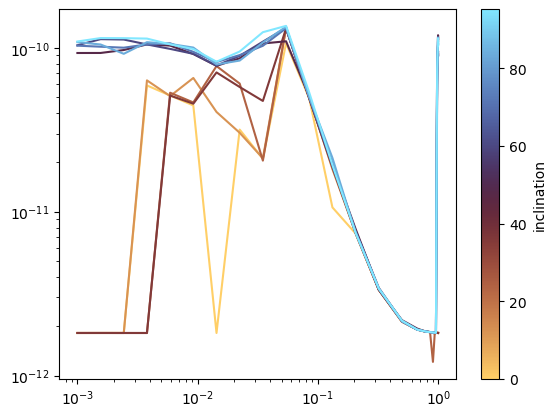

In [4]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

fig, ax = plt.subplots()

phases = parameter_grid['phases']
inclinations = parameter_grid['inclination']

n = len(inclinations) // 2

cmap_name = 'managua'

cmap = mpl.colormaps[cmap_name]
colours = cmap(np.linspace(0, 1, n))

for i in range(n):
    ax.plot(phases, grid_array[i, :], c=colours[i])
ax.set(yscale='log', xscale='log')

cmappable = ScalarMappable(Normalize(inclinations[0], inclinations[n]))
cmappable.set_cmap(cmap_name)
plt.colorbar(cmappable, ax=ax, label='inclination')

In [6]:
folder = 'rad_transfer/WR140_3.5_periastron_grid_dense'

with open(folder + '/parameter_grid.pkl', 'rb') as inp:
    parameter_grid = pickle.load(inp)
    
parameter_grid

{'inclination': array([ 0.        ,  4.73684211,  9.47368421, 14.21052632, 18.94736842,
        23.68421053, 28.42105263, 33.15789474, 37.89473684, 42.63157895,
        47.36842105, 52.10526316, 56.84210526, 61.57894737, 66.31578947,
        71.05263158, 75.78947368, 80.52631579, 85.26315789, 90.        ]),
 'n_samples': 60,
 'phases': Array([0.001     , 0.00123899, 0.0015351 , 0.00190197, 0.00235652,
        0.00291971, 0.00361749, 0.00448204, 0.0055532 , 0.00688036,
        0.0085247 , 0.01056203, 0.01308625, 0.01621374, 0.02008866,
        0.02488966, 0.03083805, 0.03820805, 0.0473394 , 0.05865306,
        0.07267058, 0.09003815, 0.1115564 , 0.1382173 , 0.17124991,
        0.21217699, 0.26288524, 0.32571229, 0.40355439, 0.5       ,
        0.59355261, 0.66960104, 0.73142041, 0.78167306, 0.82252317,
        0.85573001, 0.88272368, 0.90466669, 0.92250405, 0.93700395,
        0.94879084, 0.95837234, 0.96616109, 0.97249253, 0.97763932,
        0.98182312, 0.98522411, 0.98798876, 0.99023

In [11]:
grid_array = xmc.read_lightcurve_grid(3.5, parameter_grid, method='periastron_dense', root_dir=folder, load=False)

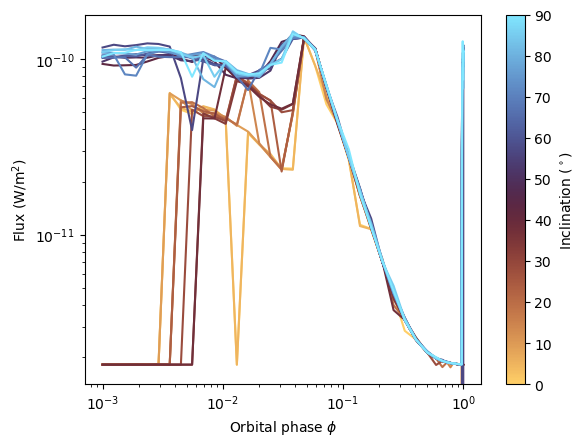

In [38]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

fig, ax = plt.subplots()

phases = parameter_grid['phases']
inclinations = parameter_grid['inclination']

n = len(inclinations)

cmap_name = 'managua'
# cmap_name = 'cool_r
cmap = mpl.colormaps[cmap_name]
colours = cmap(inclinations / np.max(inclinations))

# cmap_name = 'gist_heat'
# cmap = mpl.colormaps[cmap_name]
# colours = cmap(inclinations / np.max(1.1 * inclinations))

for i in range(n):
    ax.plot(phases, grid_array[i, :], c=colours[i])
ax.set(yscale='log', xscale='log',
      xlabel=r'Orbital phase $\phi$', ylabel=r'Flux (W/m$^2$)')

cmappable = ScalarMappable(Normalize(inclinations[0], inclinations[n-1]))
cmappable.set_cmap(cmap_name)
plt.colorbar(cmappable, ax=ax, label=r'Inclination ($^\circ$)')